# Road Crack Detection Model
##### Component 1: Crack Segmentation Model

This notebook is part of a multi-component crack detection pipeline for MOP project.

**My Role (Team Member 1):** Build the AI model that detects cracks in images and outputs binary crack masks — the foundation for all downstream components (crack metrics, RAG + LLM reporting, Streamlit interface).

**Pipeline:**
`Image → Crack Detection Model → Crack Mask → Crack Metrics → LLM Report`

**Approach:** Compare UNet + ResNet34 vs DeepLabV3+ + ResNet50 to select the best segmentation architecture and improve the performance.
**Dataset:** [Crack Segmentation Dataset](https://www.kaggle.com/datasets/lakshaymiddha/crack-segmentation-dataset)  
**Metrics:** IoU & Dice Score

## 1. Imports

In [ ]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

## 2. Environment Setup

In [ ]:
SAVE_DIR = "/kaggle/working"

In [ ]:
kaggle_username = "madhavgrover10"
kaggle_key      = "KGAT_cc1b9877adb5a805282f31212c7e210c"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials set!")

Kaggle credentials set!


In [ ]:
!pip install kaggle -q
!kaggle datasets download -d lakshaymiddha/crack-segmentation-dataset -q
print("Download done!")
!unzip -q crack-segmentation-dataset.zip
print("Unzip done!")

Dataset URL: https://www.kaggle.com/datasets/lakshaymiddha/crack-segmentation-dataset
License(s): unknown
Download done!
Unzip done!


## 3. Dataset Preparation

In [ ]:
image_dir = "crack_segmentation_dataset/train/images"
mask_dir  = "crack_segmentation_dataset/train/masks"

image_files = [f for f in os.listdir(image_dir)
               if not f.startswith('non_crack') and
               f.lower().endswith(('.jpg', '.png'))]

print("Total images:", len(image_files))

Total images: 9603


In [ ]:
train_images, val_images = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))

Train images: 7682
Validation images: 1921


## 4. Transforms

In [ ]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Dataset Class & DataLoaders

In [ ]:
class CrackDataset(Dataset):

    def __init__(self, image_dir, mask_dir, image_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform

        self.image_list = []
        skipped = 0
        for img_name in image_list:
            mask_path = os.path.join(mask_dir, img_name)
            if cv2.imread(mask_path, 0) is not None:
                self.image_list.append(img_name)
            else:
                skipped += 1
        print(f"Valid pairs: {len(self.image_list)} | Skipped: {skipped}")

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name   = self.image_list[idx]
        image_path = os.path.join(self.image_dir, img_name)
        mask_path  = os.path.join(self.mask_dir,  img_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, 0)
        mask[mask > 0] = 1

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image     = augmented["image"]
            mask      = augmented["mask"]

        return image.float(), mask.unsqueeze(0).float()

In [ ]:
train_dataset = CrackDataset(image_dir, mask_dir, train_images, transform=train_transform)
val_dataset   = CrackDataset(image_dir, mask_dir, val_images,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Sanity check
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask  batch shape:", masks.shape)

Valid pairs: 7682 | Skipped: 0
Valid pairs: 1921 | Skipped: 0
Image batch shape: torch.Size([32, 3, 224, 224])
Mask  batch shape: torch.Size([32, 1, 224, 224])


## 6. Sample Visualisation

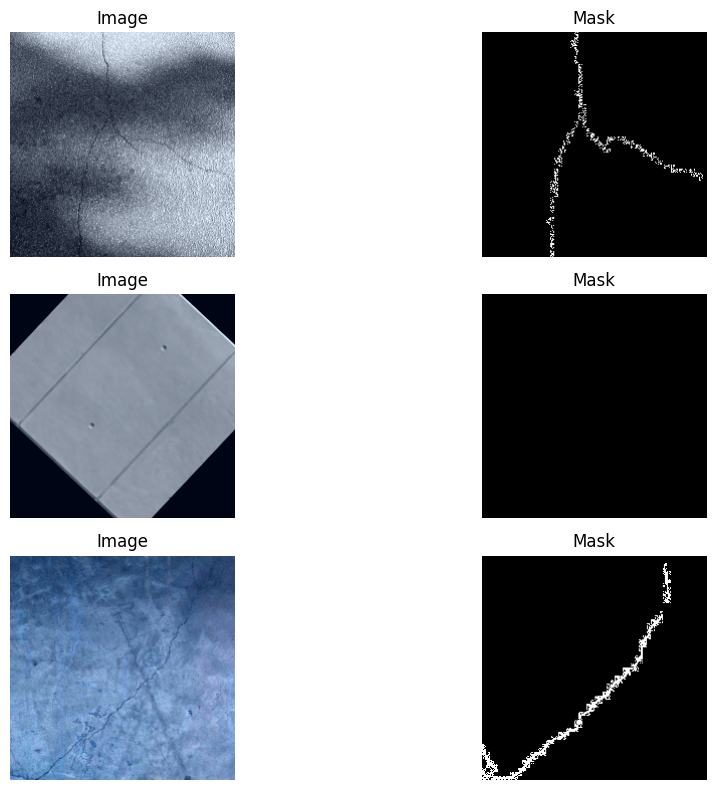

In [ ]:
plt.figure(figsize=(12, 8))
images, masks = next(iter(train_loader))

for i in range(3):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(img); plt.title("Image"); plt.axis("off")

    plt.subplot(3, 2, 2*i+2)
    plt.imshow(masks[i].cpu().squeeze(), cmap="gray"); plt.title("Mask"); plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Metric Functions

In [ ]:
def iou_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    intersection = (pred * mask).sum(dim=dims)
    union = pred.sum(dim=dims) + mask.sum(dim=dims) - intersection
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()

def dice_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    intersection = (pred * mask).sum(dim=dims)
    return ((2 * intersection + 1e-6) / (pred.sum(dim=dims) + mask.sum(dim=dims) + 1e-6)).mean().item()

## 8. Training Function

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_model(model, train_loader, val_loader, num_epochs=30, lr=0.0001):
    model.to(device)
    loss_fn   = smp.losses.DiceLoss(mode="binary")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_ious, val_dices = [], [], [], []

    for epoch in range(num_epochs):
        # Train
        model.train()
        epoch_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss  = loss_fn(preds, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()

        # Validate
        model.eval()
        val_loss = val_iou = val_dice = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs  = model(images)
                val_loss += loss_fn(outputs, masks).item()
                val_iou  += iou_score(outputs, masks)
                val_dice += dice_score(outputs, masks)

        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss     / len(val_loader))
        val_ious.append(val_iou        / len(val_loader))
        val_dices.append(val_dice      / len(val_loader))

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | IoU: {val_ious[-1]:.4f} | Dice: {val_dices[-1]:.4f}")

    return train_losses, val_losses, val_ious, val_dices

Using device: cuda


## 9. Model 1 — UNet + ResNet34

In [ ]:
model1 = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
train_losses1, val_losses1, val_ious1, val_dices1 = train_model(model1, train_loader, val_loader, num_epochs=15)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.7761 | Val Loss: 0.6094 | IoU: 0.5237 | Dice: 0.6578
Epoch 02 | Train Loss: 0.5087 | Val Loss: 0.4027 | IoU: 0.5570 | Dice: 0.6844
Epoch 03 | Train Loss: 0.3741 | Val Loss: 0.3290 | IoU: 0.5833 | Dice: 0.7109
Epoch 04 | Train Loss: 0.3260 | Val Loss: 0.3054 | IoU: 0.5874 | Dice: 0.7147
Epoch 05 | Train Loss: 0.3081 | Val Loss: 0.2960 | IoU: 0.5863 | Dice: 0.7121
Epoch 06 | Train Loss: 0.3029 | Val Loss: 0.2877 | IoU: 0.5893 | Dice: 0.7156
Epoch 07 | Train Loss: 0.2915 | Val Loss: 0.2783 | IoU: 0.6010 | Dice: 0.7273
Epoch 08 | Train Loss: 0.2852 | Val Loss: 0.2769 | IoU: 0.5994 | Dice: 0.7254
Epoch 09 | Train Loss: 0.2821 | Val Loss: 0.2704 | IoU: 0.6037 | Dice: 0.7296
Epoch 10 | Train Loss: 0.2823 | Val Loss: 0.2745 | IoU: 0.5971 | Dice: 0.7230
Epoch 11 | Train Loss: 0.2793 | Val Loss: 0.2715 | IoU: 0.6017 | Dice: 0.7272
Epoch 12 | Train Loss: 0.2778 | Val Loss: 0.2712 | IoU: 0.5995 | Dice: 0.7251
Epoch 13 | Train Loss: 0.2742 | Val Loss: 0.2639 | IoU: 0.6102 |

In [ ]:
torch.save(model1.state_dict(), os.path.join(SAVE_DIR, "model1_unet_resnet34.pth"))

with open(os.path.join(SAVE_DIR, "model1_history.json"), "w") as f:
    json.dump({"train_losses": train_losses1, "val_losses": val_losses1,
               "val_ious": val_ious1, "val_dices": val_dices1}, f)

print("Model 1 saved!")
print(f"Best IoU:  {max(val_ious1):.4f}  (Epoch {val_ious1.index(max(val_ious1))+1})")
print(f"Best Dice: {max(val_dices1):.4f}  (Epoch {val_dices1.index(max(val_dices1))+1})")

Model 1 saved!
Best IoU:  0.6102  (Epoch 13)
Best Dice: 0.7348  (Epoch 13)


### Model 1 — Training Curves

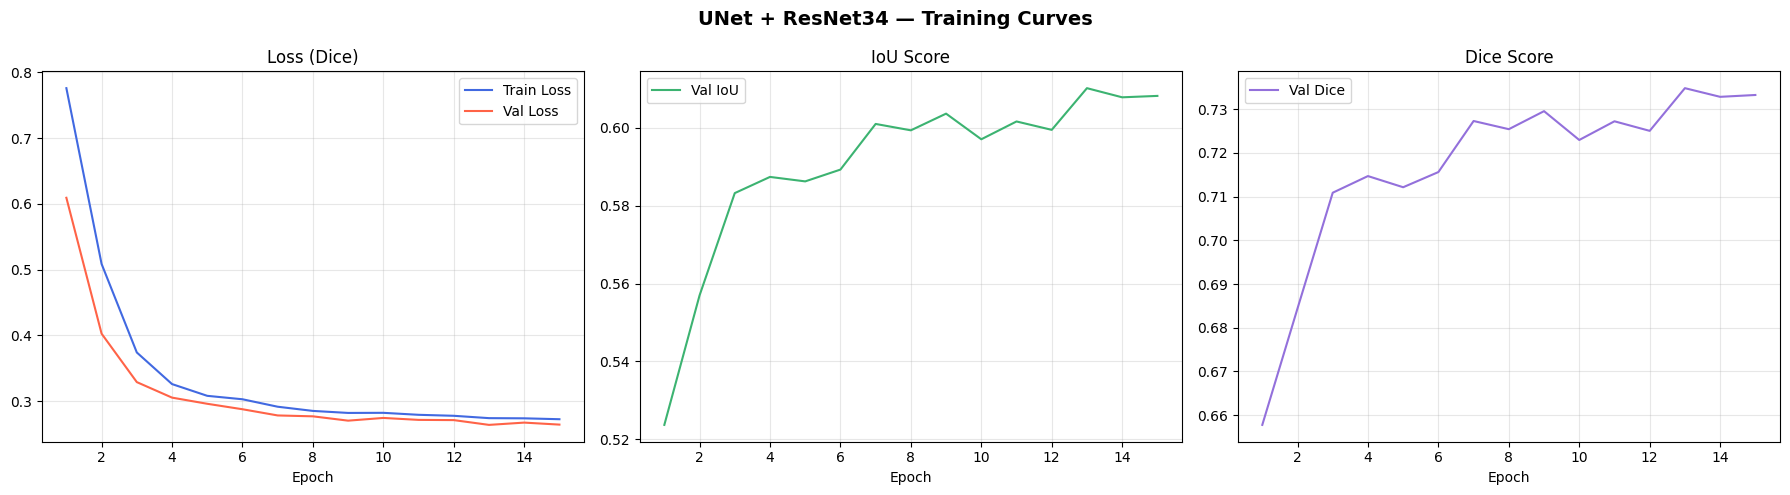

In [ ]:
epochs1 = range(1, len(train_losses1) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UNet + ResNet34 — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs1, train_losses1, label="Train Loss", color="royalblue")
axes[0].plot(epochs1, val_losses1,   label="Val Loss",   color="tomato")
axes[0].set_title("Loss (Dice)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs1, val_ious1, label="Val IoU", color="mediumseagreen")
axes[1].set_title("IoU Score"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs1, val_dices1, label="Val Dice", color="mediumpurple")
axes[2].set_title("Dice Score"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model1_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Model 2 — DeepLabV3+ + ResNet50

In [ ]:
model2 = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=1)
train_losses2, val_losses2, val_ious2, val_dices2 = train_model(model2, train_loader, val_loader, num_epochs=30)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.7041 | Val Loss: 0.4863 | IoU: 0.5053 | Dice: 0.6390
Epoch 02 | Train Loss: 0.4176 | Val Loss: 0.3594 | IoU: 0.5352 | Dice: 0.6665
Epoch 03 | Train Loss: 0.3484 | Val Loss: 0.3227 | IoU: 0.5601 | Dice: 0.6895
Epoch 04 | Train Loss: 0.3240 | Val Loss: 0.3108 | IoU: 0.5644 | Dice: 0.6944
Epoch 05 | Train Loss: 0.3125 | Val Loss: 0.2964 | IoU: 0.5767 | Dice: 0.7045
Epoch 06 | Train Loss: 0.3058 | Val Loss: 0.2921 | IoU: 0.5834 | Dice: 0.7123
Epoch 07 | Train Loss: 0.2990 | Val Loss: 0.2905 | IoU: 0.5804 | Dice: 0.7078
Epoch 08 | Train Loss: 0.2970 | Val Loss: 0.2965 | IoU: 0.5755 | Dice: 0.7045
Epoch 09 | Train Loss: 0.2925 | Val Loss: 0.2819 | IoU: 0.5914 | Dice: 0.7198
Epoch 10 | Train Loss: 0.2882 | Val Loss: 0.2795 | IoU: 0.5916 | Dice: 0.7191
Epoch 11 | Train Loss: 0.2861 | Val Loss: 0.2838 | IoU: 0.5895 | Dice: 0.7185
Epoch 12 | Train Loss: 0.2867 | Val Loss: 0.2886 | IoU: 0.5857 | Dice: 0.7122
Epoch 13 | Train Loss: 0.2854 | Val Loss: 0.2805 | IoU: 0.5887 |

In [ ]:
torch.save(model2.state_dict(), os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth"))

with open(os.path.join(SAVE_DIR, "model2_history.json"), "w") as f:
    json.dump({"train_losses": train_losses2, "val_losses": val_losses2,
               "val_ious": val_ious2, "val_dices": val_dices2}, f)

print("Model 2 saved!")
print(f"Best IoU:  {max(val_ious2):.4f}  (Epoch {val_ious2.index(max(val_ious2))+1})")
print(f"Best Dice: {max(val_dices2):.4f}  (Epoch {val_dices2.index(max(val_dices2))+1})")

Model 2 saved!
Best IoU:  0.6067  (Epoch 29)
Best Dice: 0.7334  (Epoch 29)


### Model 2 — Training Curves

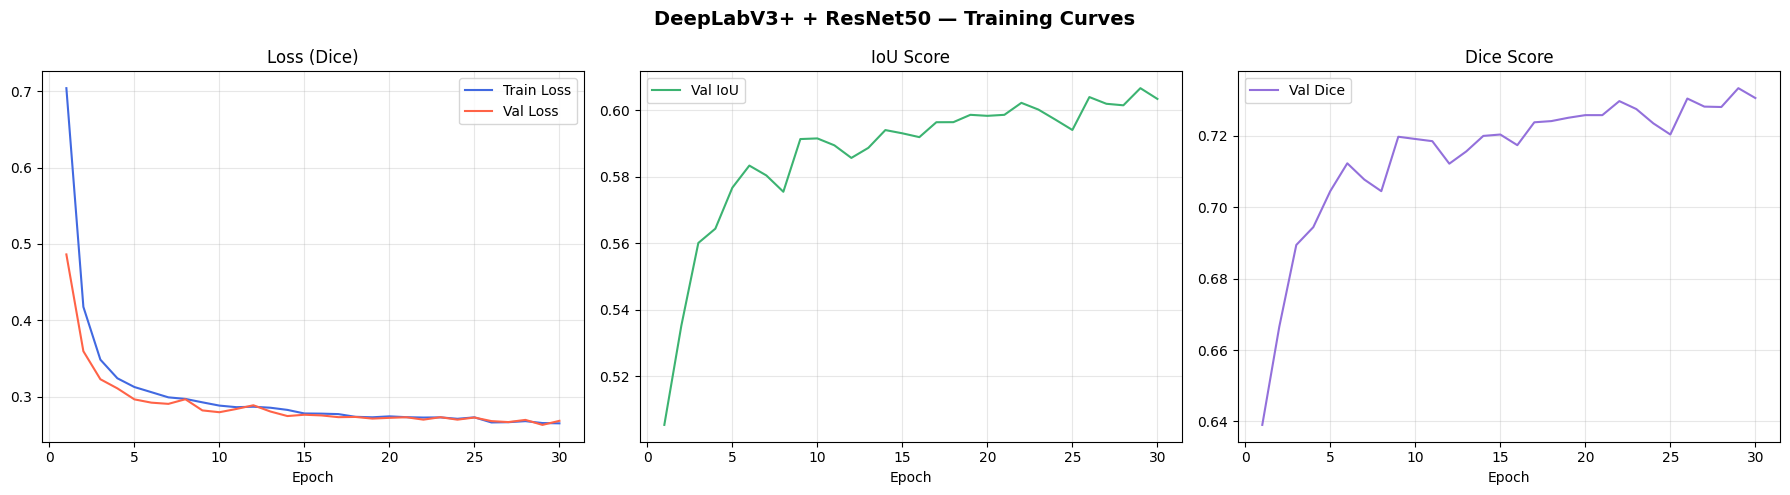

In [ ]:
epochs2 = range(1, len(train_losses2) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DeepLabV3+ + ResNet50 — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs2, train_losses2, label="Train Loss", color="royalblue")
axes[0].plot(epochs2, val_losses2,   label="Val Loss",   color="tomato")
axes[0].set_title("Loss (Dice)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs2, val_ious2, label="Val IoU", color="mediumseagreen")
axes[1].set_title("IoU Score"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs2, val_dices2, label="Val Dice", color="mediumpurple")
axes[2].set_title("Dice Score"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model2_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Model Comparison

In [ ]:
print(f"{'Model':<30} {'Best Dice':>10} {'Best IoU':>10}")
print("-" * 52)
print(f"{'UNet + ResNet34':<30} {max(val_dices1):>10.4f} {max(val_ious1):>10.4f}")
print(f"{'DeepLabV3+ + ResNet50':<30} {max(val_dices2):>10.4f} {max(val_ious2):>10.4f}")

Model                           Best Dice   Best IoU
----------------------------------------------------
UNet + ResNet34                    0.7348     0.6102
DeepLabV3+ + ResNet50              0.7334     0.6067


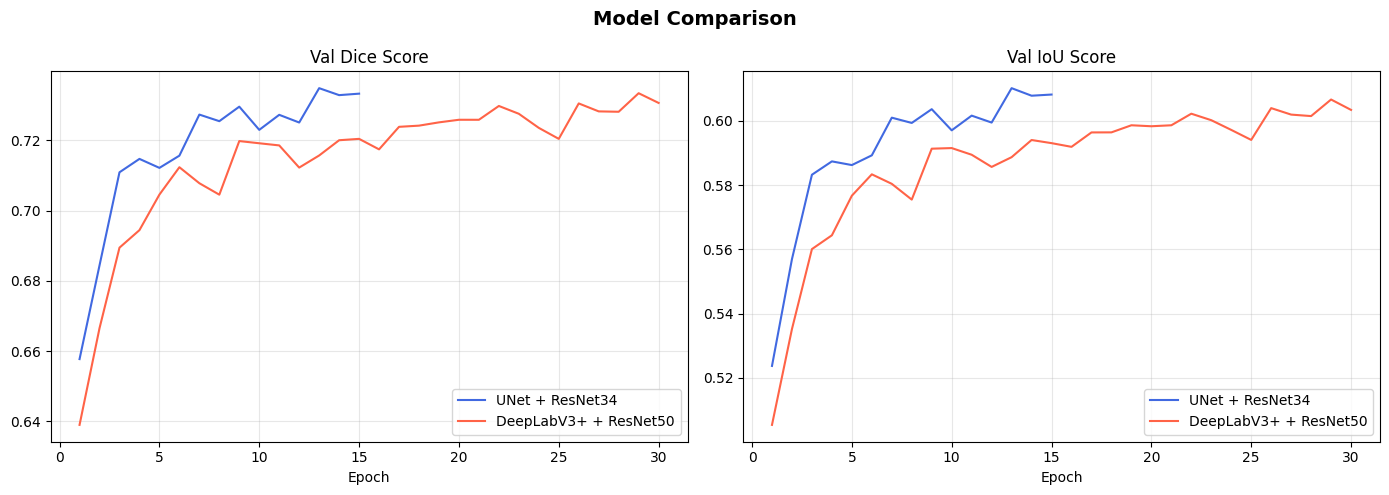

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

axes[0].plot(range(1, len(val_dices1)+1), val_dices1, label="UNet + ResNet34",       color="royalblue")
axes[0].plot(range(1, len(val_dices2)+1), val_dices2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[0].set_title("Val Dice Score"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_ious1)+1), val_ious1, label="UNet + ResNet34",       color="royalblue")
axes[1].plot(range(1, len(val_ious2)+1), val_ious2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[1].set_title("Val IoU Score"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()